<a href="https://colab.research.google.com/github/NandaniChavan02/TECH-INTERN/blob/main/Stock_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Stock Price Prediction**

/tmp/ipykernel_1911/1188062282.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", start="2015-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - loss: 0.0155
Epoch 2/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - loss: 6.6388e-04
Epoch 3/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - loss: 6.2416e-04
Epoch 4/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - loss: 6.0617e-04
Epoch 5/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - loss: 5.9592e-04
Epoch 6/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 5.4182e-04
Epoch 7/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 5.0714e-04
Epoch 8/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 7s 107ms/step - loss: 4.6437e-04
Epoch 9/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 4.4003e-04
Epoch 10/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - loss: 4.3840e-04
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step
Predicted Next Price: [[191.20877]]
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
Mean Squared Error (MSE): 27.923359092294778
Mean Absolute Error (MAE): 4.282786270377389


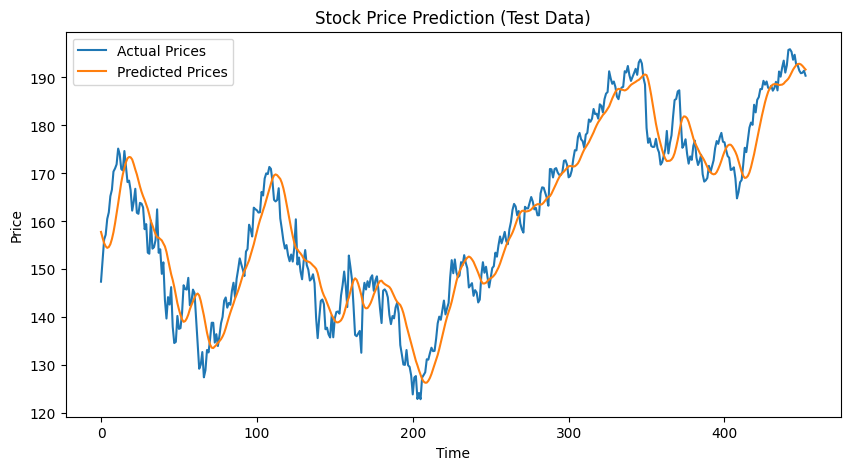

Extra features included: Close and Volume


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM


data = yf.download("AAPL", start="2015-01-01", end="2024-01-01")

prices = data['Close'].values.reshape(-1, 1)


scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(prices)


X_train = []
y_train = []

for i in range(60, len(scaled_data)):
    X_train.append(scaled_data[i-60:i, 0])
    y_train.append(scaled_data[i, 0])

X_train = np.array(X_train)
y_train = np.array(y_train)

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

model = Sequential()

model.add(LSTM(units=50, return_sequences=True,
               input_shape=(X_train.shape[1], 1)))
model.add(LSTM(units=50))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

model.fit(X_train, y_train, epochs=10, batch_size=32)

test_data = scaled_data[-60:]

X_test = []
X_test.append(test_data[:, 0])
X_test = np.array(X_test)

X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

predicted_price = model.predict(X_test)
predicted_price = scaler.inverse_transform(predicted_price)

print("Predicted Next Price:", predicted_price)


train_size = int(len(scaled_data) * 0.8)

train_data = scaled_data[:train_size]
test_data_full = scaled_data[train_size - 60:]

X_test_full = []
y_test_full = []

for i in range(60, len(test_data_full)):
    X_test_full.append(test_data_full[i-60:i, 0])
    y_test_full.append(test_data_full[i, 0])

X_test_full = np.array(X_test_full)
y_test_full = np.array(y_test_full)

X_test_full = X_test_full.reshape(
    (X_test_full.shape[0], X_test_full.shape[1], 1)
)

predicted_prices_full = model.predict(X_test_full)
predicted_prices_full = scaler.inverse_transform(predicted_prices_full)

actual_prices_full = scaler.inverse_transform(
    y_test_full.reshape(-1, 1)
)

from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(actual_prices_full, predicted_prices_full)
mae = mean_absolute_error(actual_prices_full, predicted_prices_full)

print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)

plt.figure(figsize=(10, 5))
plt.plot(actual_prices_full, label="Actual Prices")
plt.plot(predicted_prices_full, label="Predicted Prices")

plt.title("Stock Price Prediction (Test Data)")
plt.xlabel("Time")
plt.ylabel("Price")

plt.legend()
plt.show()

features = data[['Close', 'Volume']]

scaler_features = MinMaxScaler()
scaled_features = scaler_features.fit_transform(features)

print("Extra features included: Close and Volume")